# TC3002B Fact-Checking Model
Angel Mauricio Ramírez Herrera | A01710158

## 1. Propósito del Proyecto  

El objetivo de este proyecto es desarrollar un modelo de **Procesamiento de Lenguaje Natural (NLP)** capaz de detectar desinformación en afirmaciones científicas escritas en lenguaje natural.

El sistema busca clasificar automáticamente afirmaciones en tres categorías:

- **Supported** → La afirmación está respaldada por consenso científico.
- **Refuted** → La afirmación contradice evidencia científica establecida.
- **Not Enough Evidence** → No existe evidencia suficiente para confirmar o refutar la afirmación.

Este proyecto tiene como finalidad:

- Contribuir al desarrollo de sistemas automatizados de verificación científica.
- Explorar técnicas de clasificación multiclase en NLP.
- Evaluar distintos enfoques de modelado (TF-IDF + ML, Deep Learning, Transformers).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import mixed_precision
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow import keras
import kagglehub
import os

2026-04-13 02:47:30.393267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776048450.681890      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776048450.768717      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776048451.511994      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776048451.512037      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776048451.512040      16 computation_placer.cc:177] computation placer alr

In [2]:
def get_dir_size(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total += os.path.getsize(fp)
    return total

def count_empty(df):
    return df.select([
        sum(when(trim(col(c)) == "", 1).otherwise(0)).alias(c)
        for c in df.columns if dict(df.dtypes)[c] == 'string'
    ])

# 2. Dataset Utilizado: SCVD-11K  

Se utilizó el **Scientific Claim Verification Dataset (SCVD-11K)**, un dataset estructurado para clasificación de afirmaciones científicas.

## Resumen del Dataset

- 10,000 muestras de entrenamiento  
- 1,000 muestras de prueba  
- Total: 11,000 afirmaciones etiquetadas  
- Sin entradas duplicadas  
- Idioma: Inglés  
- Distribución de clases: Balanceada


In [3]:
# Download latest version
path = kagglehub.dataset_download("sudhanshuyadav09/scientific-fact-check-classification-dataset")

print("Path to dataset files:", path)

size_bytes = get_dir_size(path)
size_mb = size_bytes / (1024 * 1024)

print(f"Tamaño total de los archivos: {size_mb:.2f} MB")

Path to dataset files: /kaggle/input/datasets/sudhanshuyadav09/scientific-fact-check-classification-dataset
Tamaño total de los archivos: 0.84 MB


In [4]:
files = os.listdir(path)
print(files)
train = [f for f in files if f.endswith('.csv')][1]
train_path = os.path.join(path, train)

test = [f for f in files if f.endswith('.csv')][0]
test_path = os.path.join(path, test)

['scientific_claim_test.csv', 'scientific_claim_train.csv']


# 3. Estructura y Formato de los Datos  

## Archivos

- `scientific_claim_train.csv` → Datos para entrenamiento (10,000 filas)
- `scientific_claim_test.csv` → Datos para evaluación (1,000 filas)

In [5]:
df_train = pd.read_csv(
    train_path,
    on_bad_lines='skip',
    low_memory=False
)

df_train.shape

(10000, 2)

In [6]:
df_test = pd.read_csv(
    test_path,
    on_bad_lines='skip',
    low_memory=False
)

df_test.shape

(1000, 2)

# 4. Unión de Datasets  

Se unificaron los conjuntos de entrenamiento y prueba con el objetivo de:

- Realizar un Análisis Exploratorio de Datos (EDA) completo.
- Analizar distribución global de clases.
- Detectar posibles inconsistencias o anomalías.
- Aplicar tokenización de manera uniforme.
- Garantizar consistencia en el preprocesamiento.

Posteriormente, para el entrenamiento del modelo, se respetó la separación original entre train y test.

In [7]:
df_merged = pd.concat([df_train, df_test], ignore_index=True)

In [8]:
df_merged.shape

(11000, 2)

## Columnas

| Columna     | Tipo     | Descripción |
|------------|----------|-------------|
| statement  | string   | Afirmación científica en lenguaje natural. |
| label      | string   | Etiqueta categórica (Supported, Refuted, Not Enough Evidence). |

In [9]:
df_merged.head()

,statement,label
0,Dark matter might interact weakly with normal ...,Not Enough Evidence
1,The Earth is flat. (Statement ID 5654),Refuted
2,Climate change is a hoax created by scientists...,Refuted
3,Some diets might improve long-term health outc...,Not Enough Evidence
4,A new vaccine candidate may reduce infection r...,Not Enough Evidence


In [10]:
df_merged.tail()

,statement,label
10995,Goldfish have a memory span of only three seco...,Refuted
10996,The Earth revolves around the Sun. (Statement ...,Supported
10997,Photosynthesis allows plants to convert sunlig...,Supported
10998,Lightning never strikes the same place twice. ...,Refuted
10999,A new vaccine candidate may reduce infection r...,Not Enough Evidence


In [11]:
(df_merged.isnull().sum() / len(df_merged) * 100).round(2).sort_values(ascending = False)

statement    0.0
label        0.0
dtype: float64

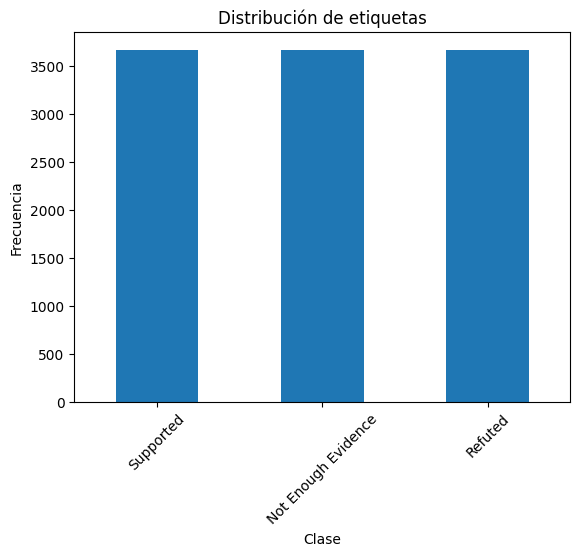

In [12]:
df_merged['label'].value_counts().plot(kind='bar')

plt.title('Distribución de etiquetas')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

# 5. Justificación del Procesamiento de Datos  

El procesamiento es una etapa en proyectos de NLP porque los modelos no trabajan directamente con texto crudo, sino con representaciones numéricas.

## 5.1 Lowercasing  

Se convirtió todo el texto a minúsculas para:

- Reducir la dimensionalidad del vocabulario.
- Evitar que el modelo trate como diferentes palabras:
  - `Vaccine`
  - `vaccine`

In [13]:
df_merged['statement_clean'] = (
    df_merged['statement']
    .str.replace(r'\(Statement ID \d+\)$', '', regex=True)
    .str.replace(r'\[.*?\]', '', regex=True)
    .str.replace(r'\n+', ' ', regex=True)
    .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.lower()
)

In [14]:
df_merged.head(20)

,statement,label,statement_clean
0,Dark matter might interact weakly with normal ...,Not Enough Evidence,dark matter might interact weakly with normal ...
1,The Earth is flat. (Statement ID 5654),Refuted,the earth is flat
2,Climate change is a hoax created by scientists...,Refuted,climate change is a hoax created by scientists
3,Some diets might improve long-term health outc...,Not Enough Evidence,some diets might improve long term health outc...
4,A new vaccine candidate may reduce infection r...,Not Enough Evidence,a new vaccine candidate may reduce infection r...
5,Gravity causes objects to fall toward the Eart...,Supported,gravity causes objects to fall toward the earth
6,Photosynthesis allows plants to convert sunlig...,Supported,photosynthesis allows plants to convert sunlig...
7,A new particle could exist beyond the Standard...,Not Enough Evidence,a new particle could exist beyond the standard...
8,Goldfish have a memory span of only three seco...,Refuted,goldfish have a memory span of only three seconds
9,Climate change is a hoax created by scientists...,Refuted,climate change is a hoax created by scientists
